In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score


In [3]:
df = pd.read_csv(
    "/content/twitter_training.csv",
    header=None,
    names=["ID","Topic","Sentiment","Tweet"],
    engine='python'
)

df.head()

,ID,Topic,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
df.info()

df.shape

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Topic      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


,0
ID,0
Topic,0
Sentiment,0
Tweet,686


In [5]:
df.dropna(inplace=True)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+","",text)

    text = re.sub(r"@\w+","",text)

    text = re.sub(r"#","",text)

    text = re.sub(r"[^a-zA-Z ]","",text)

    text = re.sub(r"\s+"," ",text)

    return text

In [8]:
df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

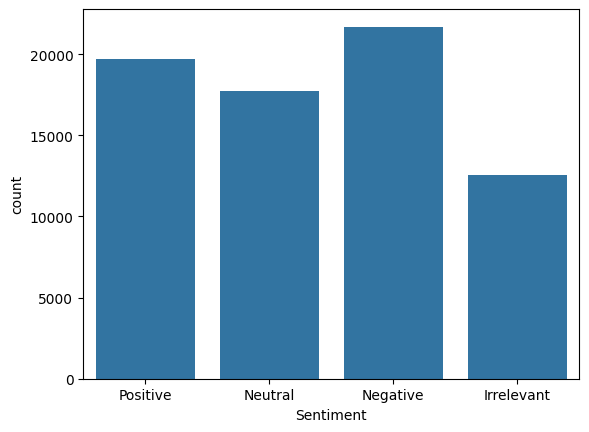

In [9]:
sns.countplot(
    data=df,
    x="Sentiment"
)

plt.show()

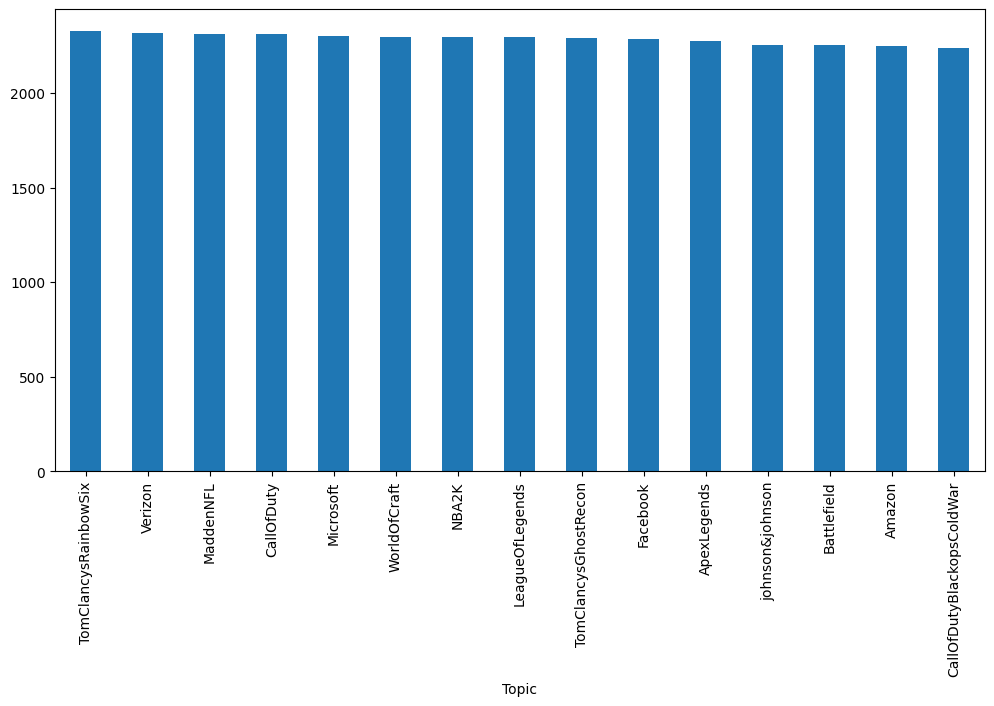

In [10]:
plt.figure(figsize=(12,6))

df["Topic"].value_counts().head(15).plot(kind="bar")

plt.show()

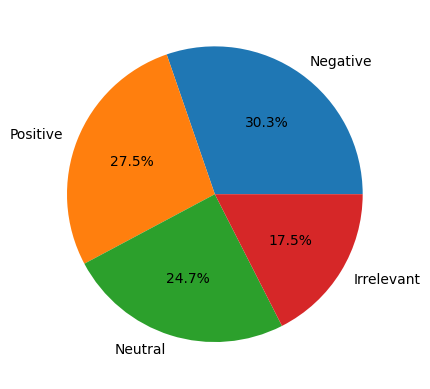

In [11]:
df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.show()

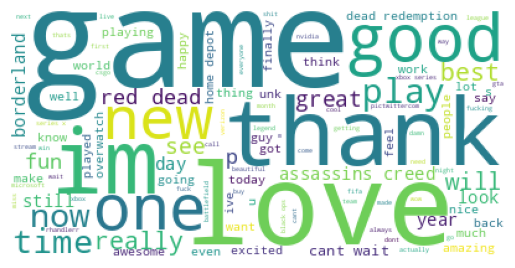

In [12]:
positive = " ".join(
    df[df["Sentiment"]=="Positive"]["Clean_Tweet"]
)

wc = WordCloud(
    background_color="white"
)

plt.imshow(wc.generate(positive))
plt.axis("off")
plt.show()


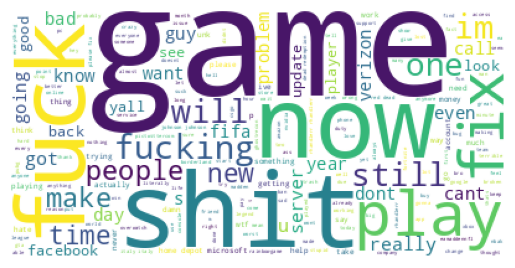

In [15]:
negative = " ".join(
    df[df["Sentiment"]=="Negative"]["Clean_Tweet"]
)

wc = WordCloud(
    background_color="white"
)

plt.imshow(wc.generate(negative))
plt.axis("off")
plt.show()

In [16]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [17]:
from nltk.corpus import stopwords

stop_words = stopwords.words("english")

In [18]:
def remove_stopwords(text):

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["Clean_Tweet"] = df["Clean_Tweet"].apply(remove_stopwords)

In [19]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Tweet"])

y = df["Sentiment"]

In [21]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
model = LogisticRegression(max_iter=500)

model.fit(X_train,y_train)

LogisticRegression(max_iter=500)

In [23]:
pred = model.predict(X_test)

In [24]:
accuracy_score(y_test,pred)


0.6762489533910131

In [25]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

  Irrelevant       0.69      0.50      0.58      2529
    Negative       0.68      0.80      0.74      4383
     Neutral       0.67      0.61      0.64      3543
    Positive       0.67      0.71      0.69      3877

    accuracy                           0.68     14332
   macro avg       0.68      0.66      0.66     14332
weighted avg       0.68      0.68      0.67     14332



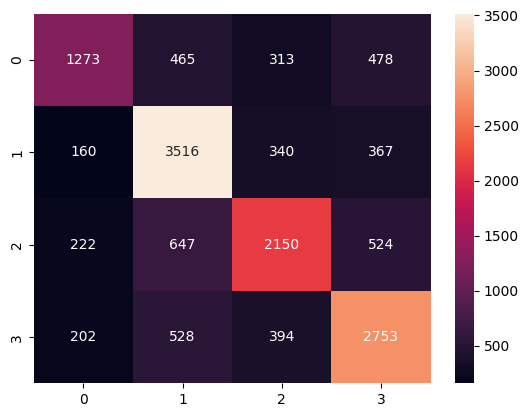

In [26]:
sns.heatmap(
    confusion_matrix(y_test,pred),
    annot=True,
    fmt="d"
)

plt.show()

In [27]:
tweet = ["This game is amazing"]

vector = tfidf.transform(tweet)

model.predict(vector)

array(['Positive'], dtype=object)

In [28]:
df["Tweet_Length"] = df["Clean_Tweet"].apply(lambda x: len(str(x).split()))

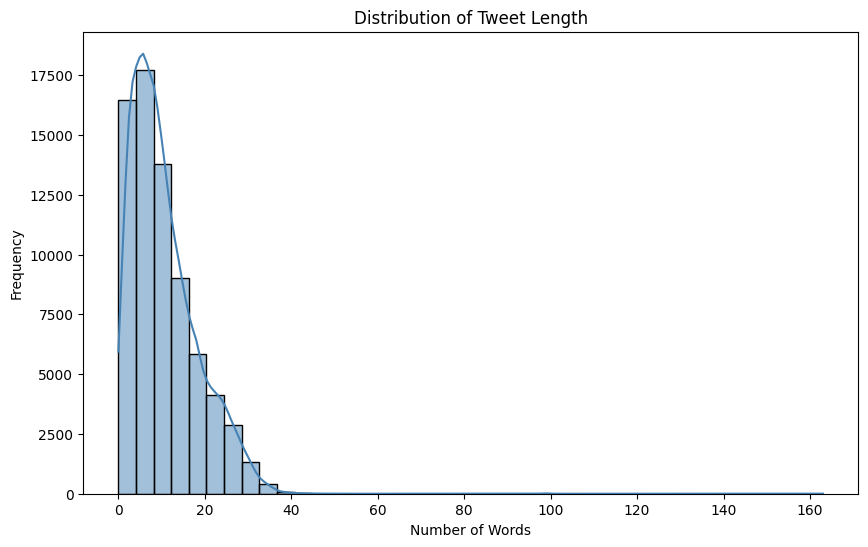

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Tweet_Length",
    bins=40,
    color="steelblue",
    kde=True
)

plt.title("Distribution of Tweet Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [30]:
sentiment_topic = pd.crosstab(df["Topic"], df["Sentiment"])

In [31]:
top_topics = df["Topic"].value_counts().head(15).index

sentiment_topic = sentiment_topic.loc[top_topics]

<Figure size 1400x800 with 0 Axes>

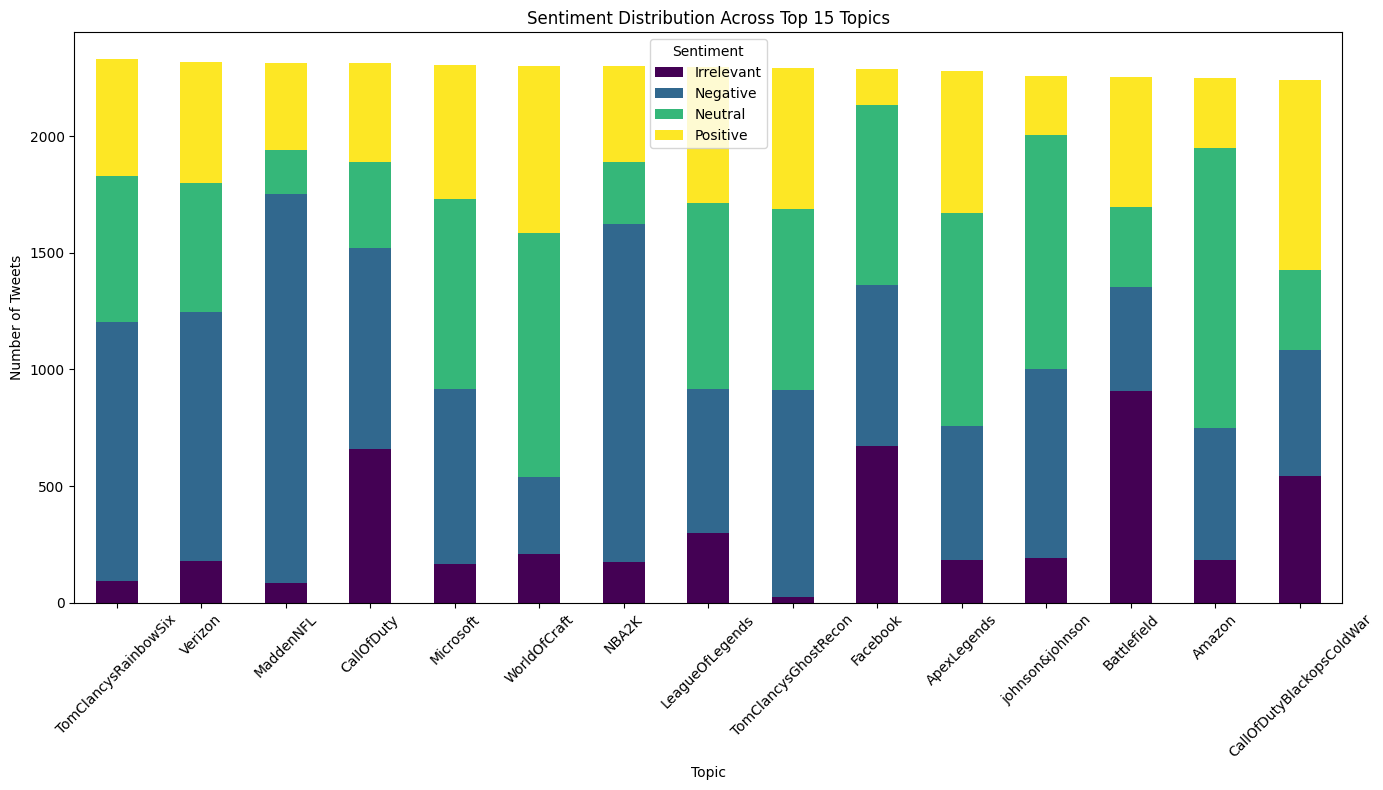

In [32]:
plt.figure(figsize=(14,8))

sentiment_topic.plot(
    kind="bar",
    stacked=True,
    figsize=(14,8),
    colormap="viridis"
)

plt.title("Sentiment Distribution Across Top 15 Topics")

plt.xlabel("Topic")

plt.ylabel("Number of Tweets")

plt.xticks(rotation=45)

plt.legend(title="Sentiment")

plt.tight_layout()

plt.show()

In [33]:
from collections import Counter

In [34]:
positive_words = " ".join(
    df[df["Sentiment"]=="Positive"]["Clean_Tweet"]
).split()

word_counts = Counter(positive_words)

top_positive = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word","Count"]
)

/tmp/ipykernel_5076/1885420447.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


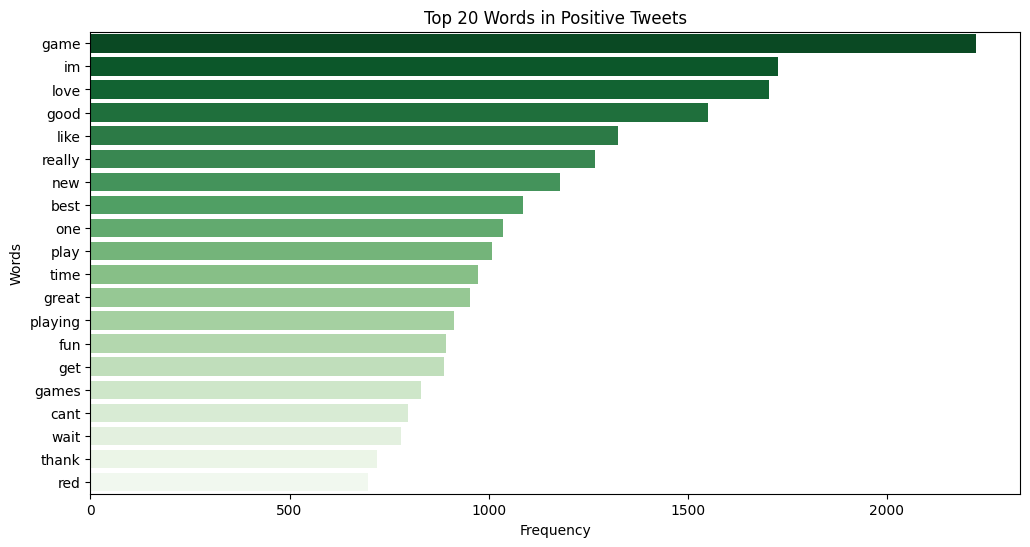

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_positive,
    x="Count",
    y="Word",
    palette="Greens_r"
)

plt.title("Top 20 Words in Positive Tweets")

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.show()

In [36]:
negative_words = " ".join(
    df[df["Sentiment"]=="Negative"]["Clean_Tweet"]
).split()

word_counts = Counter(negative_words)

top_negative = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word","Count"]
)

/tmp/ipykernel_5076/2364090007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


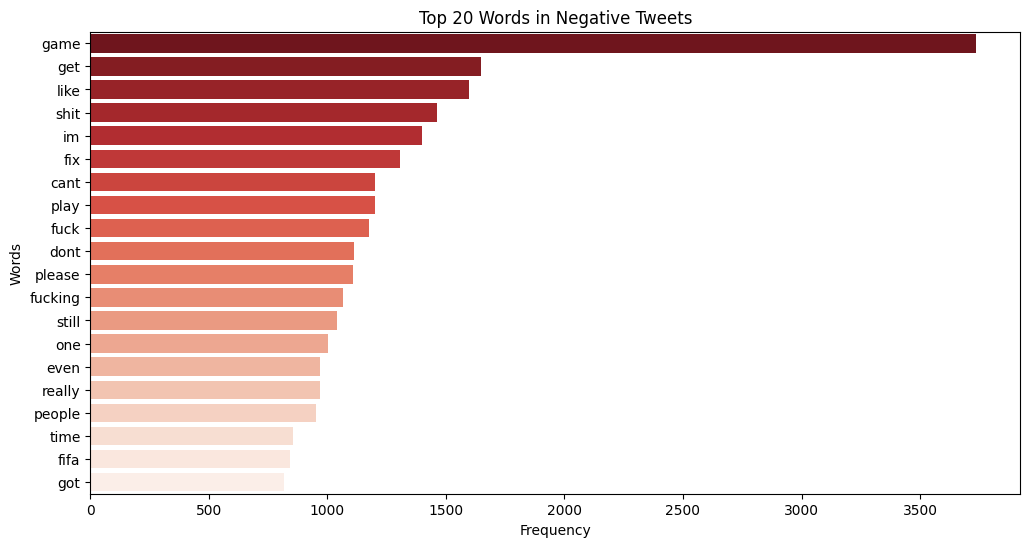

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_negative,
    x="Count",
    y="Word",
    palette="Reds_r"
)

plt.title("Top 20 Words in Negative Tweets")

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.show()

In [38]:
avg_length = (
    df.groupby("Sentiment")["Tweet_Length"]
      .mean()
      .sort_values(ascending=False)
)

/tmp/ipykernel_5076/1094681154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


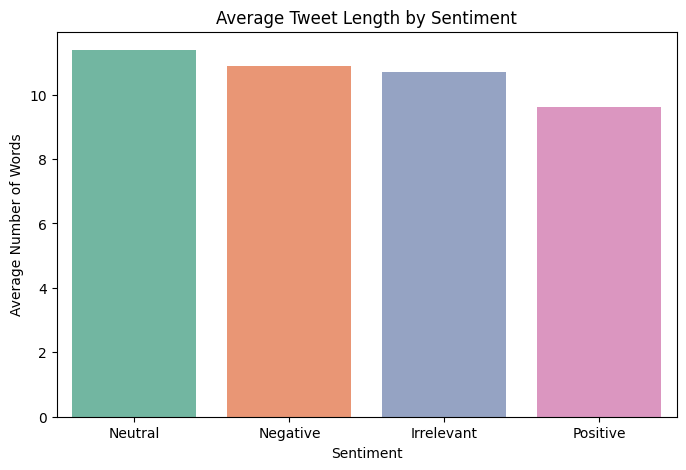

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_length.index,
    y=avg_length.values,
    palette="Set2"
)

plt.title("Average Tweet Length by Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Average Number of Words")

plt.show()